### Carga del conjunto de datos

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving test.csv to test (1).csv
Saving train.csv to train (1).csv


### Librerias

In [17]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Preprocesamiento

El preprocesamiento del conjunto de datos es importante para que el modelo pueda trabajar adecuadamente para realizar la predicción del mejor movimiento de ajedrez.

El conjunto de datos cuanta con: el estado de la partida en nombreglatura FEN y el mejor movimiento posible en notación algebraica

## Nombreglatura FEN

> EJEMPLO:
>
> rnbqkbnr/ppppp2p/8/5pp1/4P3/8/PPPP1PPP/RNBQKBNR w KQkq - 0 3

Esta conformada por seis partes separadas por un espacio:
1. Posición del tablero separado por '/'
    - Mayusculas para blancas, minusculas para negras
    - K/k para el rey
    - Q/q para la reina
    - R/r para la torre
    - N/n para el caballo
    - P/p para el peón
    - B/b para el alfil
2. De quien es el turno
    - 'w' blancas
    - 'b' negras
3. Si hay enroque
    - K enroque blanco corto
    - k enroque negro corto
    - Q enroque blanco largo
    - q enroque negro largo
    - '-' ninguno disponible
4. Captura el paso con la casilla objetiva del peón que avanzó previamente en notación algebraica
    - Por ejemplo: e6
5. Semimovimientos desde el ultimo avance de peón o captura, se usa para la regla de 50 movimientos
6. Número de la jugada

CNN necesita de tensores para funcionar, estos los modelamos por medio de la nombreglatura. Esto nos da como resultado un tensor de 8x8x12, doce por las piezas de ajedrez (6 negras y 6 blancas) y 8x8 por las casillas del tablero de ajedrez.


In [ ]:
def fen_to_tensor(fen: str):
    # Tensor con las piezas y el tablero de ajedrez
    parts = fen.split()
    tensor = np.zeros((8, 8, 12), dtype=np.float32)

    # Identificador de las piezas
    PIECES = {
        'P':0,'N':1,'B':2,'R':3,'Q':4,'K':5,
        'p':6,'n':7,'b':8,'r':9,'q':10,'k':11
    }

    for row_idx, row in enumerate(parts[0].split('/')):
        col = 0
        for ch in row:
            if ch.isdigit():
                col += int(ch)
            else:
                tensor[row_idx, col, PIECES[ch]] = 1.0
                col += 1
    return tensor  # (8, 8, 12)

def fen_to_metadata(fen: str):
    # Metadatos del FEN
    parts = fen.split()
    turn, castling, ep = parts[1], parts[2], parts[3]
    return np.array([
        1.0 if turn == 'w' else 0.0,
        float('K' in castling),
        float('Q' in castling),
        float('k' in castling),
        float('q' in castling),
        float(ep != '-'),
    ], dtype=np.float32)  # (6,)

# Modelo

CNN por que AlphaZero lo utiliza

In [ ]:
def build_chess_cnn(num_classes=4096): # 64 de origen x 64 de destino
    # Input del tensor 8x8x12
    board_input = keras.Input(shape=(8, 8, 12), name="board")

    '''
    Conv2D: detecta patrones, primero unos simples, luego más abstractos
    BatchNormalization: normaliza los valores de las convoluciones
    LeakyReLU: introduce no linealidad, deja pasar valores negativos
    kernel_size: mira los vecinos que tiene (3x3, 5x5, etc.)
    '''
    x = layers.Conv2D(64, kernel_size=3, padding="same")(board_input)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU()(x)

    x = layers.Conv2D(64, kernel_size=3, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU()(x)

    x = layers.Conv2D(64, kernel_size=3, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU()(x)

    x = layers.Conv2D(64, kernel_size=3, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU()(x)

    # Colapsa el tablero entero, para cada canal calcula el promedio
    x = layers.GlobalAveragePooling2D()(x)

    # introducción de los metadatos
    meta_input = keras.Input(shape=(6,), name="meta")
    x = layers.Concatenate()([x, meta_input])

    '''
    Dense: mezcla toda la información en 256 neuronas
    Dropout: apaga el 20% de las neuronas aleatoriamente
    Softmax: convierte cada movimiento posible en probabilidades
    '''
    x = layers.Dense(256)(x)
    x = layers.LeakyReLU()(x)
    x = layers.Dropout(0.2)(x)
    x = layers.Dense(num_classes, activation="softmax", name="move")(x)

    # Construcción del modelo
    model = keras.Model(
        inputs={"board": board_input, "meta": meta_input},
        outputs=x
    )
    return model


model = build_chess_cnn()
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ board (InputLayer)  │ (None, 8, 8, 12)  │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 8, 8, 64)  │      6,976 │ board[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 8, 8, 64)  │        256 │ conv2d_6[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_5       │ (None, 8, 8, 64)  │          0 │ batch_normalizat… │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 8, 8, 64)  │     36,928 │ leaky_re_lu_5[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 8, 8, 64)  │        256 │ conv2d_7[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_6       │ (None, 8, 8, 64)  │          0 │ batch_normalizat… │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 8, 8, 64)  │     36,928 │ leaky_re_lu_6[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 8, 8, 64)  │        256 │ conv2d_8[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_7       │ (None, 8, 8, 64)  │          0 │ batch_normalizat… │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 8, 8, 64)  │     36,928 │ leaky_re_lu_7[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 8, 8, 64)  │        256 │ conv2d_9[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_8       │ (None, 8, 8, 64)  │          0 │ batch_normalizat… │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ leaky_re_lu_8[0]… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ meta (InputLayer)   │ (None, 6)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 70)        │          0 │ global_average_p… │
│ (Concatenate)       │                   │            │ meta[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 256)       │     18,176 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_9       │ (None, 256)       │          0 │ dense_1[0][0]     │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 256)       │          0 │ leaky_re_lu_9[0]… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 1,189,632 (4.54 MB)

 Trainable params: 1,189,120 (4.54 MB)

 Non-trainable params: 512 (2.00 KB)

In [16]:
# Obtiene el indice de una casilla
def square_to_index(square: str) -> int:
    col = ord(square[0]) - ord('a')
    row = int(square[1]) - 1
    return row * 8 + col

# Obtiene el indice de un movimiento
def move_to_index(move_str: str) -> int:
    from_idx = square_to_index(move_str[:2])
    to_idx   = square_to_index(move_str[2:4])
    return from_idx * 64 + to_idx

# Carga los datos y los divide en tableros, metadatos y mejor movimiento
def load_dataset(csv_path):
    df = pd.read_csv(csv_path)

    boards = np.stack([fen_to_tensor(f) for f in df["fen"]])
    metas  = np.stack([fen_to_metadata(f) for f in df["fen"]])
    labels = np.array([move_to_index(m) for m in df["best"]])

    return boards, metas, labels

boards, metas, labels = load_dataset("train.csv")

# Split de train y validation
split = int(len(boards) * 0.9)
train_data = ({"board": boards[:split], "meta": metas[:split]}, labels[:split])
val_data   = ({"board": boards[split:], "meta": metas[split:]}, labels[split:])

In [18]:
'''
Compilar
    - Optimizer: ajusta los pesos del modelo, Adam es el estándar
    - Loss: mide que tan equivocado está el modelo, le dice al modelo cuando
            castigar cada predicción incorrecta
    - Metrics: accuracy son las veces que el modelo predice correctamente,
            top5 son las veces que el movimiento correcto estaba en el top 5
'''
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy", # clasificación multiclase
    metrics=["accuracy", keras.metrics.SparseTopKCategoricalAccuracy(k=5, name="top5")]
)

'''
Callbacks
    - EarlyStopping: monitorea el modelo para evitar que ocurra un overfitting
    - ReduceLROnPlateau: si el modelo no mejora divide los pasos a la mitad
    - ModelCheckpoint: guarda el modelo cada vez que mejora
'''
callbacks = [
    keras.callbacks.EarlyStopping(patience=7, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=4, verbose=1),
    keras.callbacks.ModelCheckpoint("best_model.keras", save_best_only=True)
]

# Entrenar
history = model.fit(
    *train_data,
    validation_data=val_data,
    epochs=50,
    batch_size=64,
    callbacks=callbacks
)

# Descarga el entrenamiento
from google.colab import files
files.download("best_model.keras")

Epoch 1/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 50s 130ms/step - accuracy: 0.0244 - loss: 6.5875 - top5: 0.0589 - val_accuracy: 0.0148 - val_loss: 7.1534 - val_top5: 0.0288 - learning_rate: 0.0010
Epoch 2/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 78s 118ms/step - accuracy: 0.0480 - loss: 5.6305 - top5: 0.1339 - val_accuracy: 0.0488 - val_loss: 5.6206 - val_top5: 0.1664 - learning_rate: 0.0010
Epoch 3/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 41s 116ms/step - accuracy: 0.1022 - loss: 4.8761 - top5: 0.2682 - val_accuracy: 0.1080 - val_loss: 5.0037 - val_top5: 0.2832 - learning_rate: 0.0010
Epoch 4/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 40s 114ms/step - accuracy: 0.1485 - loss: 4.3998 - top5: 0.3659 - val_accuracy: 0.1244 - val_loss: 4.9377 - val_top5: 0.3132 - learning_rate: 0.0010
Epoch 5/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 41s 114ms/step - accuracy: 0.1948 - loss: 4.0107 - top5: 0.4415 - val_accuracy: 0.1808 - val_loss: 4.5069 - val_top5: 0.4224 - learning_rate: 0.0010
Epoch 6/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 41s 117ms/step 

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

mejor epoch: 15
val_loss:     3.8575754165649414
val_accuracy: 0.3531999886035919
val_top5:     0.6068000197410583


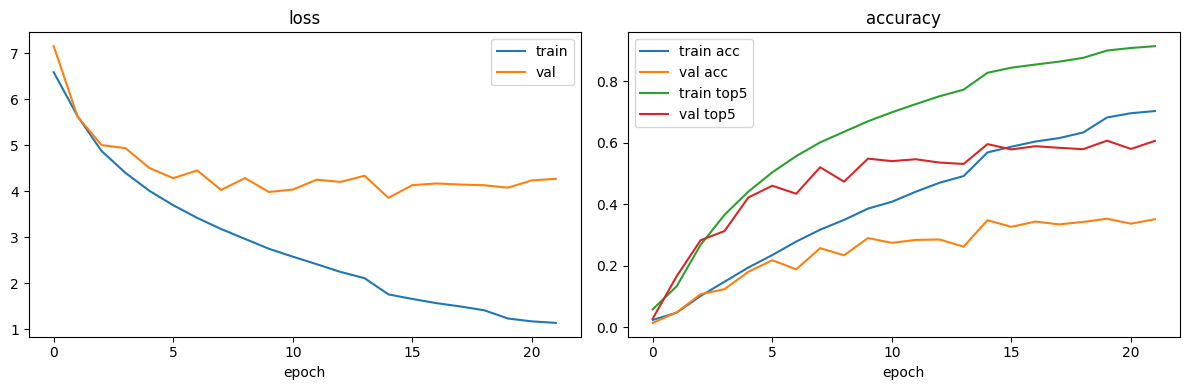

In [20]:
# Ver en qué epoch fue el mejor
print("mejor epoch:", np.argmin(history.history['val_loss']) + 1)

# Ver las métricas finales
print("val_loss:    ", min(history.history['val_loss']))
print("val_accuracy:", max(history.history['val_accuracy']))
print("val_top5:    ", max(history.history['val_top5']))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history.history['loss'],     label='train')
ax1.plot(history.history['val_loss'], label='val')
ax1.set_title('loss')
ax1.set_xlabel('epoch')
ax1.legend()

ax2.plot(history.history['accuracy'],     label='train acc')
ax2.plot(history.history['val_accuracy'], label='val acc')
ax2.plot(history.history['top5'],         label='train top5')
ax2.plot(history.history['val_top5'],     label='val top5')
ax2.set_title('accuracy')
ax2.set_xlabel('epoch')
ax2.legend()

plt.tight_layout()
plt.show()

# Referencias

1. Samara, K., Antreassian, A., Klug, M., & Hasan, M. S. (2026). Machine Learning Approaches for Classifying Chess Game Outcomes: A Comparative Analysis of Player Ratings and Game Dynamics. Electronics, 15(1), 1. https://doi.org/10.3390/electronics15010001

2. Omori, M., Tadepalli, P. (2025). Chess Rating Estimation from Moves and Clock Times Using a CNN-LSTM. In: Hartisch, M., Hsueh, CH., Schaeffer, J. (eds) Computers and Games. CG 2024 2024. Lecture Notes in Computer Science, vol 15550. Springer, Cham. https://doi.org/10.1007/978-3-031-86585-5_1